# Контрольная работа

### Задание:

**Используя данные из обучающего датасета (train.csv), построить модель для предсказания цен на недвижимость (квартиры).
С помощью полученной модели, предсказать цены для квартир из тестового датасета (test.csv).**

**Целевая переменная:**
Price

**Метрика качества:**
R2 - коэффициент детерминации (sklearn.metrics.r2_score)

**Требования к решению:**
1. R2 > 0.6
2. Тетрадка Jupyter Notebook с кодом Вашего решения, названная по образцу {ФИО}_solution.ipynb, пример SShirkin_solution.ipynb
3. Файл CSV с прогнозами целевой переменной для тестового датасета, названный по образцу {ФИО}_predictions.csv, пример SShirkin_predictions.csv 
Файл должен содержать два поля: Id, Price и в файле должна быть 5001 строка (шапка + 5000 предсказаний).

**Рекомендации для файла с кодом (ipynb):**
1. Файл должен содержать заголовки и комментарии (markdown)
2. Повторяющиеся операции лучше оформлять в виде функций
3. Не делать вывод большого количества строк таблиц (5-10 достаточно)
4. По возможности добавлять графики, описывающие данные (около 3-5)
5. Добавлять только лучшую модель, то есть не включать в код все варианты решения проекта
6. Скрипт проекта должен отрабатывать от начала и до конца (от загрузки данных до выгрузки предсказаний)
7. Весь проект должен быть в одном скрипте (файл ipynb).

**Описание датасета:**
* **Id** - идентификационный номер квартиры
* **DistrictId** - идентификационный номер района
* **Rooms** - количество комнат
* **Square** - площадь
* **LifeSquare** - жилая площадь
* **KitchenSquare** - площадь кухни
* **Floor** - этаж
* **HouseFloor** - количество этажей в доме
* **HouseYear** - год постройки дома
* **Ecology_1, Ecology_2, Ecology_3** - экологические показатели местности
* **Social_1, Social_2, Social_3** - социальные показатели местности
* **Healthcare_1, Helthcare_2** - показатели местности, связанные с охраной здоровья
* **Shops_1, Shops_2** - показатели, связанные с наличием магазинов, торговых центров
* **Price** - цена квартиры


### Предобработка данных

In [1]:
# подключим часть библиотек с которыми будем работать

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [2]:
matplotlib.rcParams.update({'font.size': 14})  # размер шрифта на графиках

In [3]:

df = pd.read_csv('train.csv')
df.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,B,B,33,7976,5,NaN,0,11,B,184966.930730
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,B,B,46,10309,1,240.0,1,16,B,300009.450063
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,B,B,34,7759,0,229.0,1,3,B,220925.908524
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,B,B,23,5735,3,1084.0,0,5,B,175616.227217
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,B,B,35,5776,1,2078.0,2,4,B,150226.531644
5,12915,59,3.0,80.384479,46.683720,12.0,5,17.0,2011,0.309479,B,B,35,7715,4,990.0,0,6,B,215898.447742
6,14549,154,2.0,62.254114,37.160377,7.0,3,5.0,1960,0.460556,B,B,20,4386,14,NaN,1,5,B,296021.204377
7,11993,74,2.0,80.312926,NaN,0.0,14,0.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B,221244.156664
8,5172,1,2.0,64.511437,NaN,1.0,9,17.0,1977,0.007122,B,B,1,264,0,NaN,0,1,B,229102.795999
9,8649,23,1.0,46.461409,18.915552,8.0,13,17.0,2014,0.075779,B,B,6,1437,3,NaN,0,2,B,95380.220993


In [4]:
# выведем общую информацию по датасету с параметром точного размера загруженных данных

df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

In [5]:
# проверим на уникальность
df['Id'].nunique()

10000

По информации о данных мы видим признаки которые нужно обработать:

Признаки с пропусками:
*  LifeSquare
*  Healthcare_1
  

Признаки с типом object:
* Ecology_2
* Ecology_3
* Shops_2

Полных дубликкатов нет, все объекты уникальные!

Обратим внимание на признаки Id и DistrictId , которые впоследствии возможно удалим!!

### Обзор количественных переменных

Выделим числовые признаки и проведем их анализ

In [6]:
df.dtypes

Id                 int64
DistrictId         int64
Rooms            float64
Square           float64
LifeSquare       float64
KitchenSquare    float64
Floor              int64
HouseFloor       float64
HouseYear          int64
Ecology_1        float64
Ecology_2         object
Ecology_3         object
Social_1           int64
Social_2           int64
Social_3           int64
Healthcare_1     float64
Helthcare_2        int64
Shops_1            int64
Shops_2           object
Price            float64
dtype: object

In [7]:
df_num_features = df.select_dtypes(include=['float64', 'int64'])
df_num_features.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,33,7976,5,NaN,0,11,184966.930730
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,46,10309,1,240.0,1,16,300009.450063
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,34,7759,0,229.0,1,3,220925.908524
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,23,5735,3,1084.0,0,5,175616.227217
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,35,5776,1,2078.0,2,4,150226.531644
5,12915,59,3.0,80.384479,46.683720,12.0,5,17.0,2011,0.309479,35,7715,4,990.0,0,6,215898.447742
6,14549,154,2.0,62.254114,37.160377,7.0,3,5.0,1960,0.460556,20,4386,14,NaN,1,5,296021.204377
7,11993,74,2.0,80.312926,NaN,0.0,14,0.0,1977,0.075779,6,1437,3,NaN,0,2,221244.156664
8,5172,1,2.0,64.511437,NaN,1.0,9,17.0,1977,0.007122,1,264,0,NaN,0,1,229102.795999
9,8649,23,1.0,46.461409,18.915552,8.0,13,17.0,2014,0.075779,6,1437,3,NaN,0,2,95380.220993


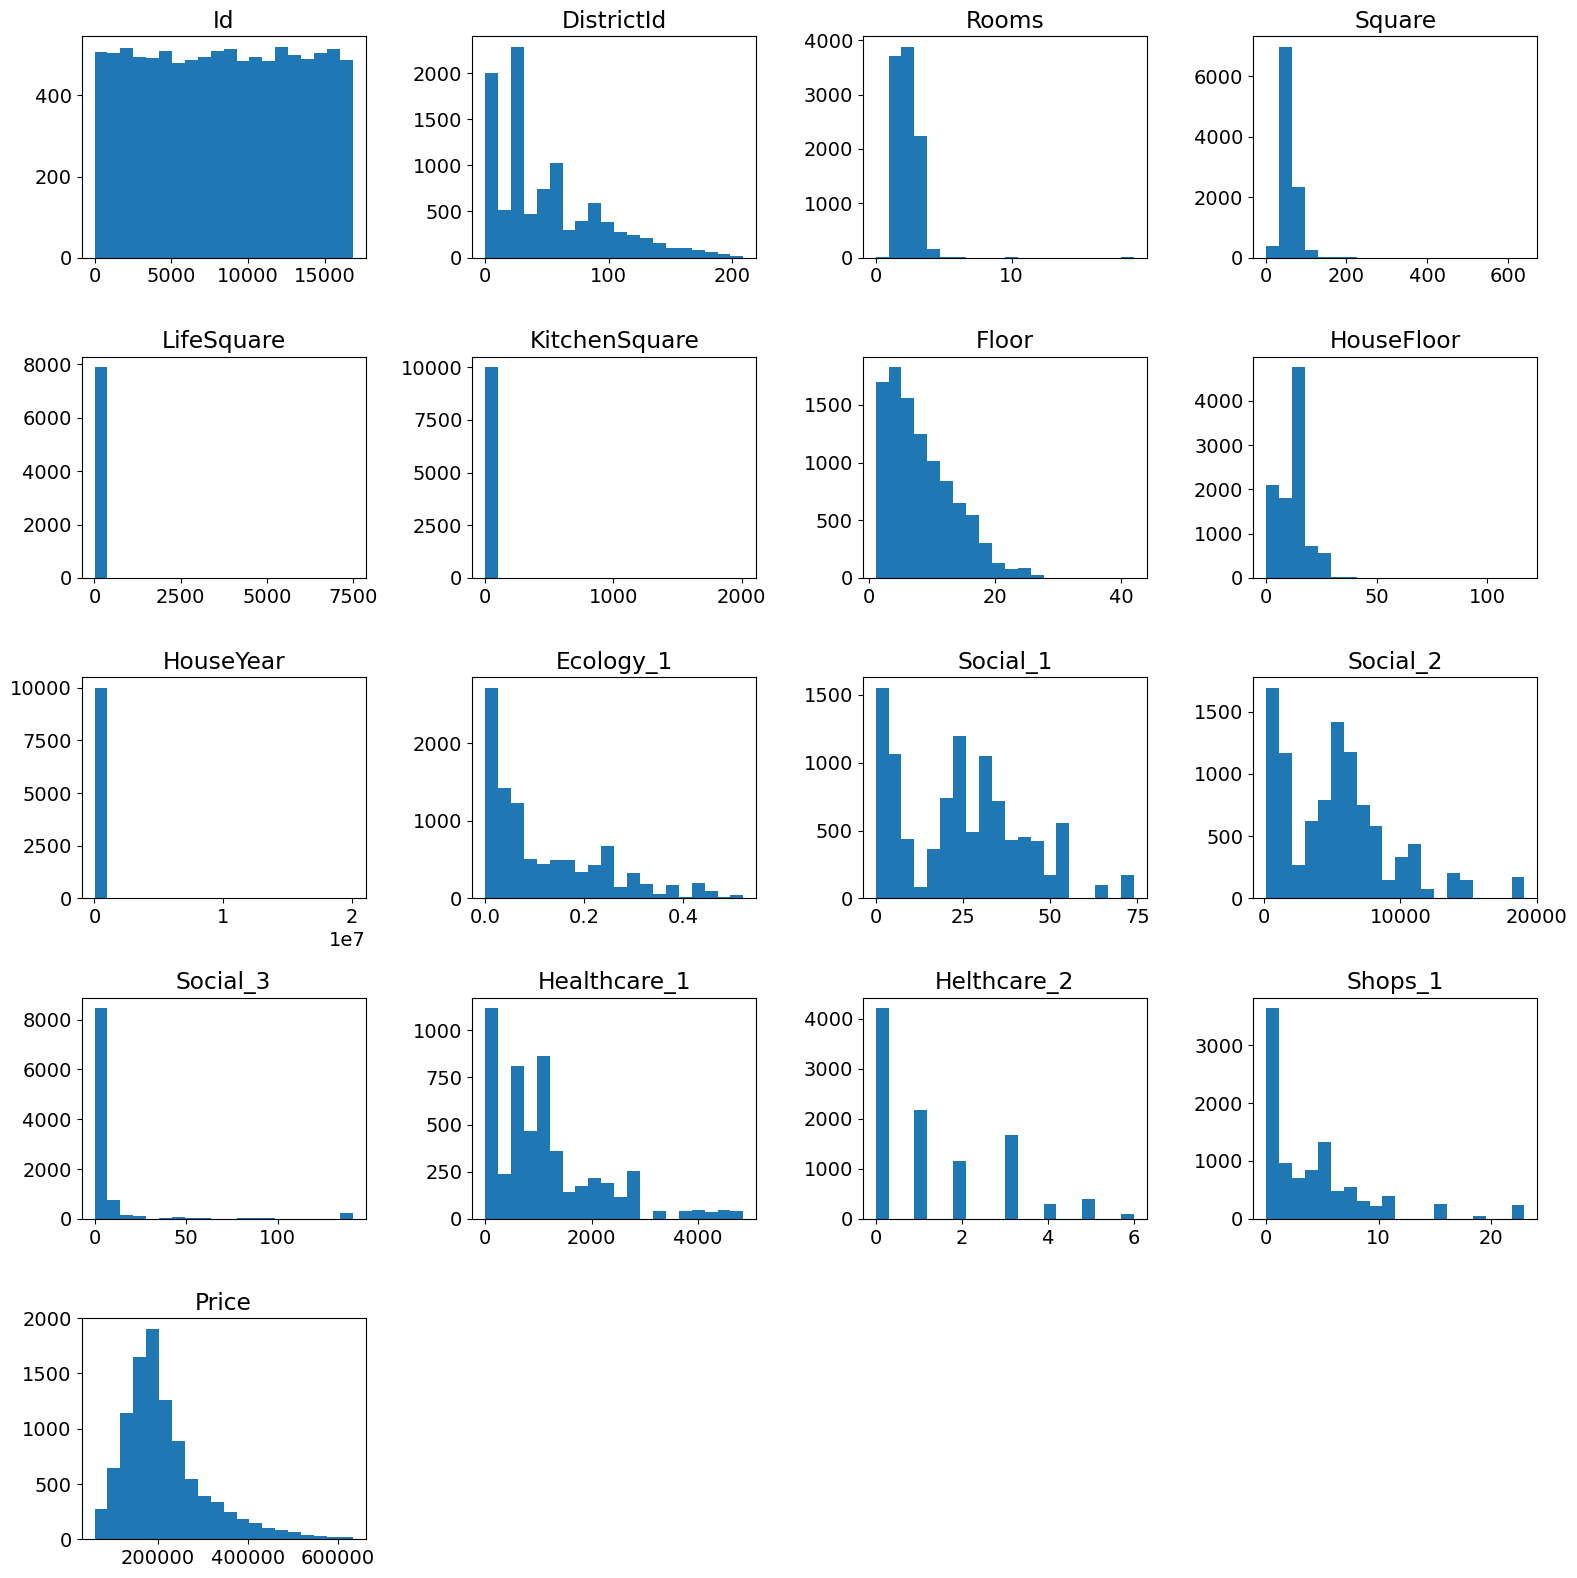

In [8]:
df_num_features.hist(figsize=(16, 16), bins=20, grid=False)
plt.tight_layout()  # Это улучшит расположение графитов
plt.show()

In [9]:
# отобразим данные в меньшем формате
df_num_features.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.47


сейчас более наглядно видно что во многих признаках присутствуют аномалии и их нужно обработать!

### Обзор категориальных переменных

In [10]:
df_obj_features = df.select_dtypes(include='object')
df_obj_features.head()

,Ecology_2,Ecology_3,Shops_2
0,B,B,B
1,B,B,B
2,B,B,B
3,B,B,B
4,B,B,B


In [11]:
df_obj_features['Ecology_2'].value_counts()

Ecology_2
B    9903
A      97
Name: count, dtype: int64

In [12]:
df_obj_features['Ecology_3'].value_counts()

Ecology_3
B    9725
A     275
Name: count, dtype: int64

In [13]:
df_obj_features['Shops_2'].value_counts()

Shops_2
B    9175
A     825
Name: count, dtype: int64

В категориальных признаках каких-либо анамалий нет

### Обработка пропусков

In [14]:
df.isnull().sum()

Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare       2113
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64

Заметим что в двух признаках пропуски имеют большое количество и не совсем понятно что с ними делать!

Рассмотрим вариант с заменой пропусков в признаке LifeSquare на медиану, а признак Healthcare_1  удалим

In [15]:
df.loc[df['LifeSquare'].isnull(), 'LifeSquare'] = df['LifeSquare'].median()

In [16]:
df.isnull().sum()

Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare          0
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64

In [17]:
df = df.drop('Healthcare_1', axis=1)

In [18]:
df.isnull().sum()

Id               0
DistrictId       0
Rooms            0
Square           0
LifeSquare       0
KitchenSquare    0
Floor            0
HouseFloor       0
HouseYear        0
Ecology_1        0
Ecology_2        0
Ecology_3        0
Social_1         0
Social_2         0
Social_3         0
Helthcare_2      0
Shops_1          0
Shops_2          0
Price            0
dtype: int64

### Обработка выбросов

In [19]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,36.27,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,76.61,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,25.53,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,41.43,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,6.00,23.00,633233.47


**Rooms**

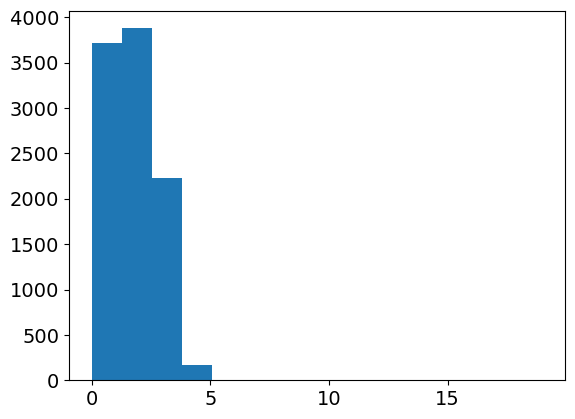

In [20]:
plt.hist(df["Rooms"], bins=15, ec='white')
plt.show()

In [21]:
df.loc[df['Rooms'] > 5, 'Rooms'] = df['Rooms'].median()

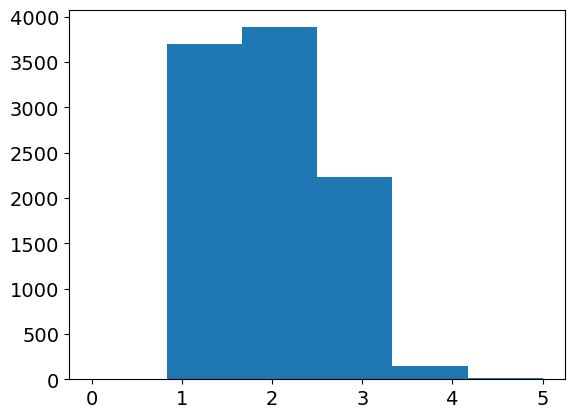

In [22]:
plt.hist(df["Rooms"], bins=6, ec='white')
plt.show()

**Square**

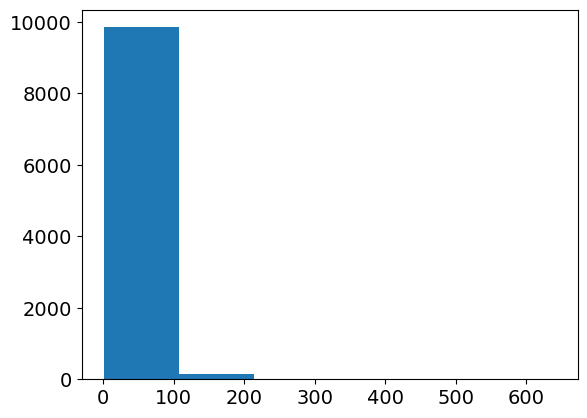

In [23]:
plt.hist(df["Square"], bins=6, ec='white')
plt.show()

In [24]:
df.loc[df['Square'] > 170, 'Square'] = df['Square'].median()

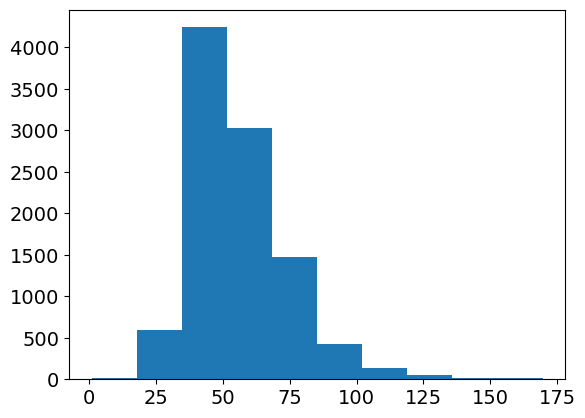

In [25]:
plt.hist(df["Square"], bins=10, ec='white')
plt.show()

**LifeSquare**

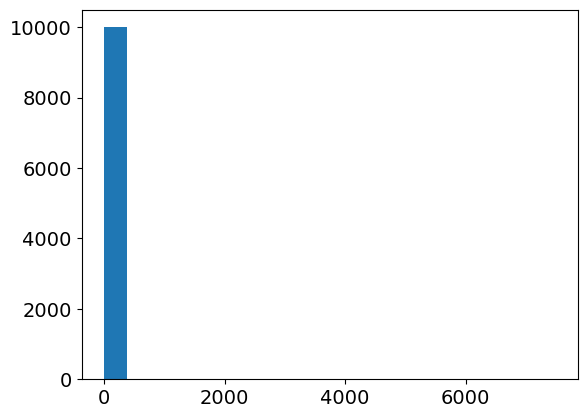

In [26]:
plt.hist(df["LifeSquare"], bins=20, ec='white')
plt.show()

In [27]:
df.loc[df['LifeSquare'] > 150, 'LifeSquare'] = df['LifeSquare'].median()

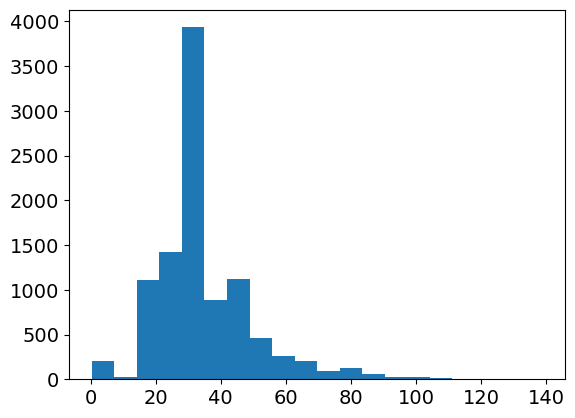

In [28]:
plt.hist(df["LifeSquare"], bins=20, ec='white')
plt.show()

**KitchenSquare**

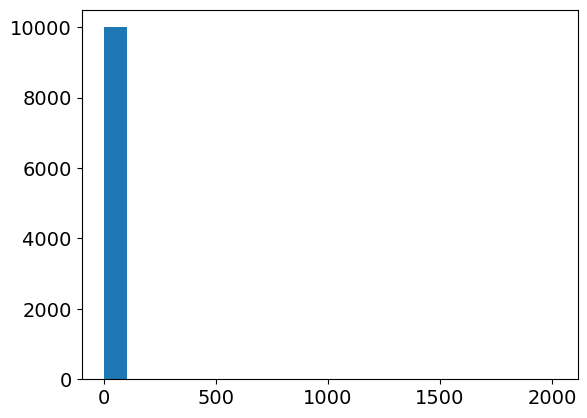

In [29]:
plt.hist(df['KitchenSquare'], bins=20, ec='white')
plt.show()

In [30]:
df.loc[df['KitchenSquare'] > 50, 'KitchenSquare'] = df['KitchenSquare'].median()

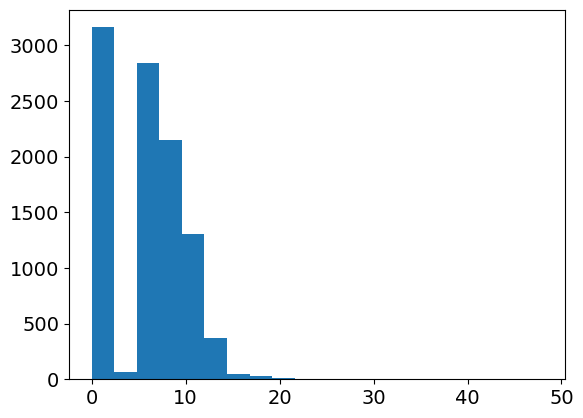

In [31]:
plt.hist(df['KitchenSquare'], bins=20, ec='white')
plt.show()

**Floor**

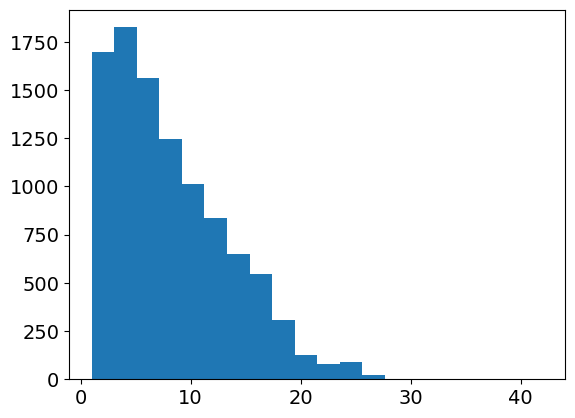

In [32]:
plt.hist(df['Floor'], bins=20, ec='white')
plt.show()

In [33]:
df.loc[df['Floor'] > 28, 'Floor'] = df['Floor'].median()

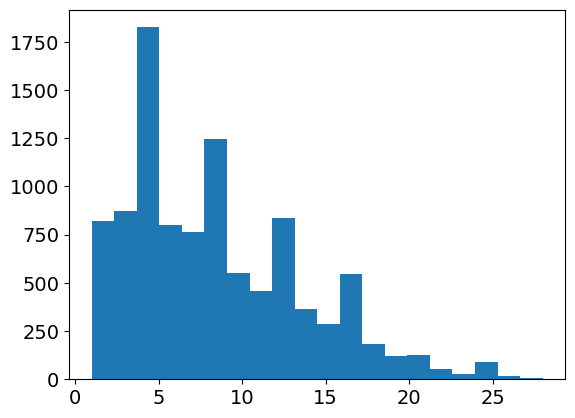

In [34]:
plt.hist(df['Floor'], bins=20, ec='white')
plt.show()

**HouseFloor**

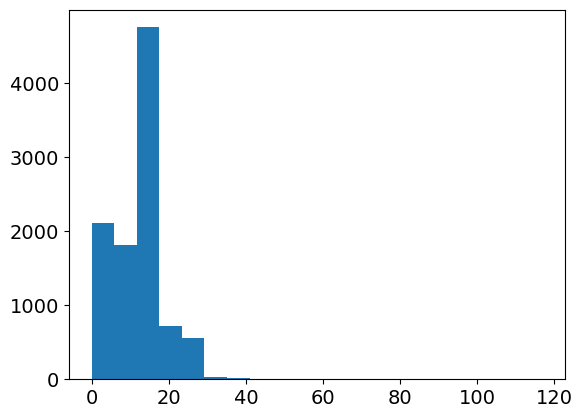

In [35]:
plt.hist(df['HouseFloor'], bins=20, ec='white')
plt.show()

In [36]:
df.loc[df['HouseFloor'] > 35, 'HouseFloor'] = df['HouseFloor'].median()

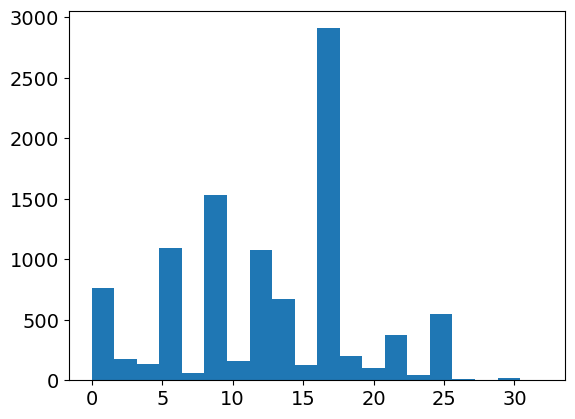

In [37]:
plt.hist(df['HouseFloor'], bins=20, ec='white')
plt.show()

**HouseYear**

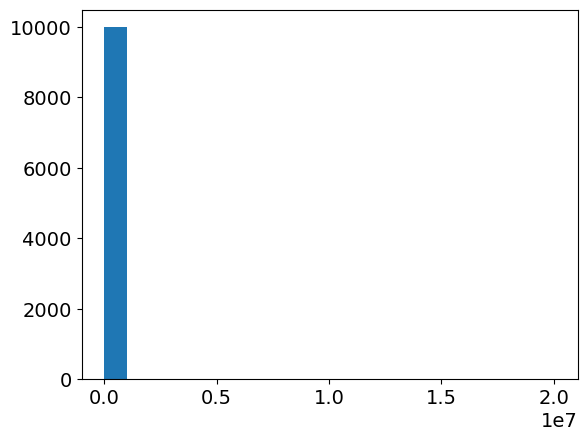

In [38]:
plt.hist(df['HouseYear'], bins=20, ec='white')
plt.show()

In [39]:
df.loc[df['HouseYear'] > 2024, 'HouseYear'] = df['HouseYear'].median()

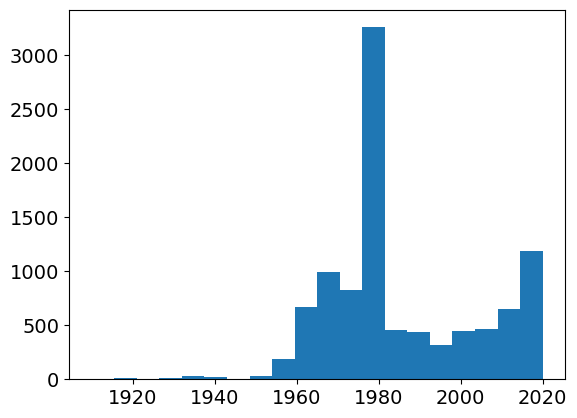

In [40]:
plt.hist(df['HouseYear'], bins=20, ec='white')
plt.show()

**Social_3**

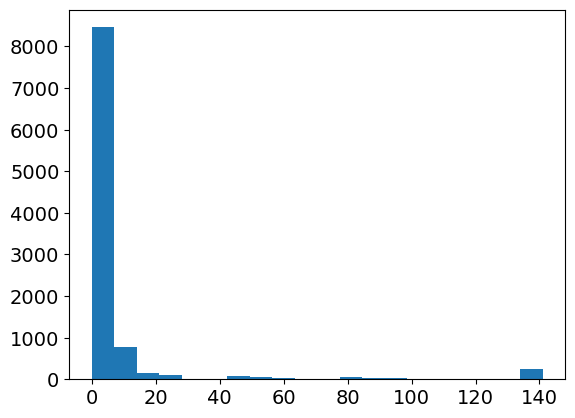

In [41]:
plt.hist(df['Social_3'], bins=20, ec='white')
plt.show()

In [42]:
df.loc[df['Social_3'] > 30, 'Social_3'] = df['Social_3'].median()

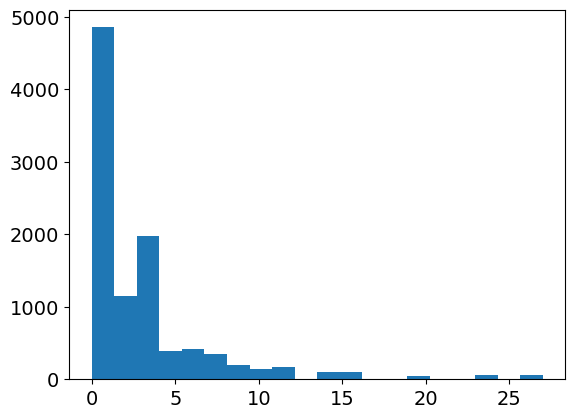

In [43]:
plt.hist(df['Social_3'], bins=20, ec='white')
plt.show()

**Ecology_2, Ecology_3, Shops_2**

In [44]:
df

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,B,B,33,7976,5,0,11,B,184966.930730
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,B,B,46,10309,1,1,16,B,300009.450063
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,B,B,34,7759,0,1,3,B,220925.908524
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,B,B,23,5735,3,0,5,B,175616.227217
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,B,B,35,5776,1,2,4,B,150226.531644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,77,32,2.0,50.401785,30.476203,5.0,6,5.0,1968,0.135650,B,B,46,7960,6,3,11,B,196684.316040
9996,6159,18,1.0,41.521546,20.539216,9.0,13,13.0,2000,0.000000,B,B,30,5562,0,0,5,A,189050.289571
9997,5123,27,1.0,47.939008,32.781260,1.0,12,16.0,2015,0.072158,B,B,2,629,1,0,0,A,159143.805370
9998,5400,75,2.0,43.602562,33.840147,8.0,1,5.0,1961,0.307467,B,A,30,5048,9,2,5,B,181595.339808


In [45]:
df = pd.get_dummies(df, columns=['Ecology_2'], prefix='Ecology_2')
df = pd.get_dummies(df, columns=['Ecology_3'], prefix='Ecology_3')
df = pd.get_dummies(df, columns=['Shops_2'], prefix='Shops_2')

In [46]:
df

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,...,Social_3,Helthcare_2,Shops_1,Price,Ecology_2_A,Ecology_2_B,Ecology_3_A,Ecology_3_B,Shops_2_A,Shops_2_B
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,...,5,0,11,184966.930730,False,True,False,True,False,True
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,...,1,1,16,300009.450063,False,True,False,True,False,True
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,...,0,1,3,220925.908524,False,True,False,True,False,True
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,...,3,0,5,175616.227217,False,True,False,True,False,True
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,...,1,2,4,150226.531644,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,77,32,2.0,50.401785,30.476203,5.0,6,5.0,1968,0.135650,...,6,3,11,196684.316040,False,True,False,True,False,True
9996,6159,18,1.0,41.521546,20.539216,9.0,13,13.0,2000,0.000000,...,0,0,5,189050.289571,False,True,False,True,True,False
9997,5123,27,1.0,47.939008,32.781260,1.0,12,16.0,2015,0.072158,...,1,0,0,159143.805370,False,True,False,True,True,False
9998,5400,75,2.0,43.602562,33.840147,8.0,1,5.0,1961,0.307467,...,9,2,5,181595.339808,False,True,True,False,False,True


In [47]:
df.head(5)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,...,Social_3,Helthcare_2,Shops_1,Price,Ecology_2_A,Ecology_2_B,Ecology_3_A,Ecology_3_B,Shops_2_A,Shops_2_B
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,...,5,0,11,184966.930730,False,True,False,True,False,True
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,...,1,1,16,300009.450063,False,True,False,True,False,True
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,...,0,1,3,220925.908524,False,True,False,True,False,True
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,...,3,0,5,175616.227217,False,True,False,True,False,True
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,...,1,2,4,150226.531644,False,True,False,True,False,True


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     10000 non-null  float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Social_1       10000 non-null  int64  
 11  Social_2       10000 non-null  int64  
 12  Social_3       10000 non-null  int64  
 13  Helthcare_2    10000 non-null  int64  
 14  Shops_1        10000 non-null  int64  
 15  Price          10000 non-null  float64
 16  Ecology_2_A    10000 non-null  bool   
 17  Ecology_2_B    10000 non-null  bool   
 18  Ecology

In [50]:
df.to_csv('prepared_train.csv', index=False, encoding='utf-8')

In [51]:
df = pd.read_csv('prepared_train.csv')

In [52]:
df

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,...,Social_3,Helthcare_2,Shops_1,Price,Ecology_2_A,Ecology_2_B,Ecology_3_A,Ecology_3_B,Shops_2_A,Shops_2_B
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,...,5,0,11,184966.930730,False,True,False,True,False,True
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,...,1,1,16,300009.450063,False,True,False,True,False,True
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,...,0,1,3,220925.908524,False,True,False,True,False,True
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,...,3,0,5,175616.227217,False,True,False,True,False,True
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,...,1,2,4,150226.531644,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,77,32,2.0,50.401785,30.476203,5.0,6,5.0,1968,0.135650,...,6,3,11,196684.316040,False,True,False,True,False,True
9996,6159,18,1.0,41.521546,20.539216,9.0,13,13.0,2000,0.000000,...,0,0,5,189050.289571,False,True,False,True,True,False
9997,5123,27,1.0,47.939008,32.781260,1.0,12,16.0,2015,0.072158,...,1,0,0,159143.805370,False,True,False,True,True,False
9998,5400,75,2.0,43.602562,33.840147,8.0,1,5.0,1961,0.307467,...,9,2,5,181595.339808,False,True,True,False,False,True


In [53]:
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [54]:
df = reduce_mem_usage(df)

Memory usage of dataframe is 1.28 MB
Memory usage after optimization is: 0.62 MB
Decreased by 51.5%


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int16  
 1   DistrictId     10000 non-null  int16  
 2   Rooms          10000 non-null  float32
 3   Square         10000 non-null  float32
 4   LifeSquare     10000 non-null  float32
 5   KitchenSquare  10000 non-null  float32
 6   Floor          10000 non-null  int8   
 7   HouseFloor     10000 non-null  float32
 8   HouseYear      10000 non-null  int16  
 9   Ecology_1      10000 non-null  float32
 10  Social_1       10000 non-null  int8   
 11  Social_2       10000 non-null  int16  
 12  Social_3       10000 non-null  int8   
 13  Helthcare_2    10000 non-null  int8   
 14  Shops_1        10000 non-null  int8   
 15  Price          10000 non-null  float32
 16  Ecology_2_A    10000 non-null  float32
 17  Ecology_2_B    10000 non-null  float32
 18  Ecology

In [56]:
df

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,...,Social_3,Helthcare_2,Shops_1,Price,Ecology_2_A,Ecology_2_B,Ecology_3_A,Ecology_3_B,Shops_2_A,Shops_2_B
0,14038,35,2.0,47.981560,29.442751,6.0,7,9.0,1969,0.089040,...,5,0,11,184966.937500,0.0,1.0,0.0,1.0,0.0,1.0
1,15053,41,3.0,65.683640,40.049541,8.0,7,9.0,1978,0.000070,...,1,1,16,300009.437500,0.0,1.0,0.0,1.0,0.0,1.0
2,4765,53,2.0,44.947952,29.197611,0.0,8,12.0,1968,0.049637,...,0,1,3,220925.906250,0.0,1.0,0.0,1.0,0.0,1.0
3,5809,58,2.0,53.352982,52.731510,9.0,8,17.0,1977,0.437885,...,3,0,5,175616.234375,0.0,1.0,0.0,1.0,0.0,1.0
4,10783,99,1.0,39.649193,23.776169,7.0,11,12.0,1976,0.012339,...,1,2,4,150226.531250,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,77,32,2.0,50.401787,30.476204,5.0,6,5.0,1968,0.135650,...,6,3,11,196684.312500,0.0,1.0,0.0,1.0,0.0,1.0
9996,6159,18,1.0,41.521545,20.539215,9.0,13,13.0,2000,0.000000,...,0,0,5,189050.296875,0.0,1.0,0.0,1.0,1.0,0.0
9997,5123,27,1.0,47.939007,32.781261,1.0,12,16.0,2015,0.072158,...,1,0,0,159143.812500,0.0,1.0,0.0,1.0,1.0,0.0
9998,5400,75,2.0,43.602562,33.840149,8.0,1,5.0,1961,0.307467,...,9,2,5,181595.343750,0.0,1.0,1.0,0.0,0.0,1.0
